In [1]:
import numpy as np
import pandas as pd

In [3]:
houses = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/EXAM/version_F.csv')

In [4]:
from sklearn.model_selection import train_test_split
y = houses.price
X = houses.drop(['price','price_hilo'], axis = 1)
y_binned = pd.qcut(y, q = 100)
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    random_state=617, 
                                                    train_size=0.7, 
                                                    stratify=y_binned)

In [9]:
#Question 2
average_area = X_train['area'].mean()
print(average_area)

2735.184510727368


In [10]:
#Question 3
filtered_houses = houses[(houses['bathrooms'] >= 2) & (houses['neighborhood'] == 1)]
average_area_filtered = filtered_houses['area'].mean()
print(average_area_filtered)

2782.928252938792


In [11]:
#Question 5
median_age_by_bedrooms = houses.groupby('bedrooms')['age'].median()
print(median_age_by_bedrooms)

bedrooms
1    50.0
2    46.0
3    48.0
4    48.0
5    48.0
6    51.0
Name: age, dtype: float64


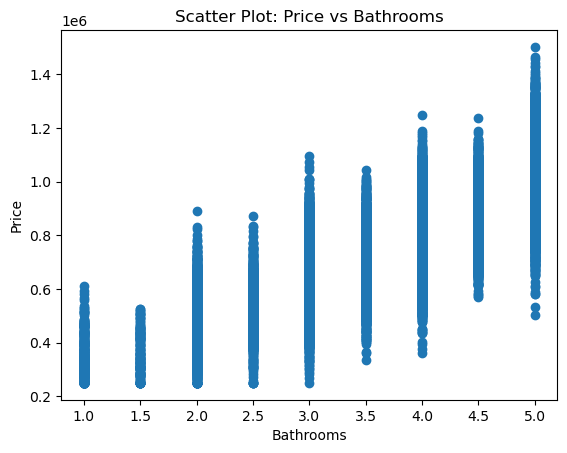

In [12]:
#Question 7
import matplotlib.pyplot as plt

train = X_train.assign(price = y_train)
test = X_test.assign(price = y_test)

plt.scatter(train['bathrooms'], train['price'])
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.title('Scatter Plot: Price vs Bathrooms')
plt.show()

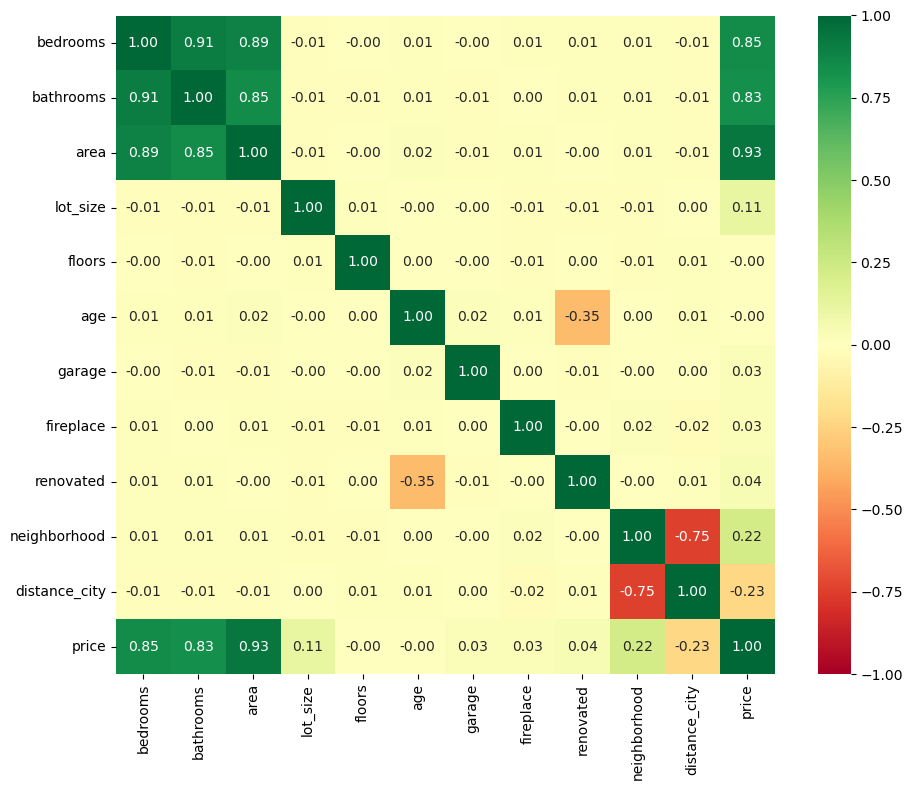

In [13]:
#Question 9
import seaborn as sns

house_train = X_train.copy()
house_train['price'] = y_train

correlation_matrix = house_train.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn",
            vmin=-1, 
            vmax=1, 
            square=True)
plt.tight_layout()
plt.show()

In [15]:
#Question 11
from sklearn.linear_model import LinearRegression

X = houses[['area']]
y = houses['price']

model1 = LinearRegression()

model1.fit(X, y)

coefficient_area = model1.coef_[0]
print(coefficient_area)

225.73368015567166


In [24]:
#Question 13
houses_dummies = pd.get_dummies(houses, columns=['neighborhood'], drop_first=True)

X = houses_dummies.drop(['price'], axis=1)
y = houses_dummies['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

model2 = LinearRegression()
model2.fit(X_train, y_train)

coefficients = model2.coef_
intercept = model2.intercept_

print(X.columns)

good_neighborhood_column = [col for col in X.columns if 'neighborhood' in col][0]
good_neighborhood_coef = coefficients[X.columns.get_loc(good_neighborhood_column)]

print(good_neighborhood_coef)

Index(['bedrooms', 'bathrooms', 'area', 'lot_size', 'floors', 'age', 'garage',
       'fireplace', 'renovated', 'distance_city', 'price_hilo',
       'neighborhood_1'],
      dtype='object')
44685.84724135943


In [25]:
#Question 15

model3 = LinearRegression()
model3.fit(X_train, y_train)

r2_score = model3.score(X_test, y_test)
print(r2_score)

0.9507014973645768


In [33]:
#Question 17
import statsmodels.api as sm
from statsmodels.formula.api import ols

houses_dummies = pd.get_dummies(houses, columns=['neighborhood'], drop_first=True)
X = houses_dummies.drop(['price'], axis=1)
y = houses_dummies['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

model3 = ols('price ~ ' + ' + '.join(X.columns), data=houses_dummies).fit()

print(model3.summary())

significant_vars = model3.pvalues[model3.pvalues < 0.05]
print(significant_vars)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 4.411e+04
Date:                Thu, 18 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:41:33   Log-Likelihood:            -3.3284e+05
No. Observations:               27300   AIC:                         6.657e+05
Df Residuals:                   27287   BIC:                         6.658e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1.42

In [38]:
#Question 19
model4 = ols('price ~ bedrooms + I(bedrooms**2) + bathrooms + I(bathrooms**2) + area + I(area**2) + lot_size + I(lot_size**2) + floors + I(floors**2) + age + I(age**2) + distance_city + I(distance_city**2)', 
             data=houses_dummies).fit()

model4_summary = model4.summary()
print(model4_summary)

quadratic_terms_pvalues = model4.pvalues.filter(like='I')

print("P-values for quadratic terms:")
print(quadratic_terms_pvalues)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 2.955e+04
Date:                Thu, 18 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:47:49   Log-Likelihood:            -3.3602e+05
No. Observations:               27300   AIC:                         6.721e+05
Df Residuals:                   27285   BIC:                         6.722e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1.961e+

In [44]:
#Question 21
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = houses[['bedrooms', 'bathrooms', 'area', 'lot_size', 'floors', 
        'age', 'garage', 'fireplace', 'renovated', 'neighborhood', 'distance_city']]

# Drop rows with NaNs to ensure the calculation runs
X = X.dropna()

# Add a constant term (intercept) for VIF calculation
X_vif = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# Exclude 'const' and sort to find the second highest
vif_results = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)

print(vif_results)

          feature       VIF
1        bedrooms  7.974861
2       bathrooms  6.293919
3            area  5.010911
11  distance_city  2.267565
10   neighborhood  2.267548
9       renovated  1.133706
6             age  1.133162
5          floors  1.000681
4        lot_size  1.000641
8       fireplace  1.000225
7          garage  1.000221


In [46]:
#Question 23
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

predictors = ['bedrooms', 'bathrooms', 'area', 'lot_size', 'floors', 'distance_city', 'age']
X = houses[predictors]
y = houses['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

lr = LinearRegression()

sfs = SFS(lr, 
          k_features='best', 
          forward=True, 
          floating=True, 
          scoring='r2',
          cv=5)

sfs.fit(X_train, y_train)

print("Selected features:", sfs.k_feature_names_)

Selected features: ('bedrooms', 'bathrooms', 'area', 'lot_size', 'floors', 'distance_city', 'age')


In [47]:
#Question 25
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

predictors = ['bedrooms', 'bathrooms', 'area', 'lot_size', 'floors', 'distance_city', 'age']
X = houses[predictors]
y = houses['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lasso = LassoCV(cv=5, random_state=617).fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({'Predictor': predictors, 'Coefficient': lasso.coef_})
print(coef_df)

       Predictor    Coefficient
0       bedrooms   10972.074996
1      bathrooms   15877.773866
2           area  176937.939222
3       lot_size   24221.824339
4         floors    -187.644601
5  distance_city  -47998.001862
6            age   -2980.212429


In [49]:
#Questiuon 27
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=4, random_state=617)
tree.fit(X_train, y_train)

importances = pd.DataFrame({'Predictor': X.columns, 'Importance': tree.feature_importances_})
print(importances.sort_values(by='Importance', ascending=False))

       Predictor  Importance
2           area    0.956387
5  distance_city    0.043613
0       bedrooms    0.000000
1      bathrooms    0.000000
3       lot_size    0.000000
4         floors    0.000000
6            age    0.000000


In [53]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

X = houses.drop(['price', 'price_hilo'], axis=1)
y = houses['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

tree = DecisionTreeRegressor(max_depth=4, random_state=617)
tree.fit(X_train, y_train)

house_to_predict = pd.DataFrame([[5, 3, 4000, 6000, 2, 30, 1, 1, 1, 1, 10]], columns=X.columns)

predicted_price = tree.predict(house_to_predict)
print(predicted_price[0])

1060461.6239419589


In [54]:
#Ques 31

import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

X = houses.drop(['price', 'price_hilo'], axis=1)
y = houses['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

tree = DecisionTreeRegressor(max_depth=4, random_state=617)
tree.fit(X_train, y_train)

house_to_predict = pd.DataFrame([[1, 1, 1000, 2000, 1, 60, 0, 0, 0, 0, 40]], columns=X.columns)

predicted_price = tree.predict(house_to_predict)
print(predicted_price[0])

407134.80967741937


In [56]:
#Ques 33

import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

X = houses.drop(['price', 'price_hilo'], axis=1)
y = houses['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

param_grid = {'max_depth': [4, 5, 6, 7, 8]}

tree = DecisionTreeRegressor(random_state=617)

grid_search = GridSearchCV(estimator=tree,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_root_mean_squared_error')

grid_search.fit(X_train, y_train)

import numpy as np
results = pd.DataFrame(grid_search.cv_results_)
results['rmse'] = -results['mean_test_score']
print(results[['param_max_depth', 'rmse']])

print("\nBest max_depth:", grid_search.best_params_['max_depth'])

   param_max_depth          rmse
0                4  70277.610954
1                5  64313.144809
2                6  61472.944064
3                7  59625.791693
4                8  58798.370911

Best max_depth: 8


In [58]:
#Ques 35
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

tree = DecisionTreeRegressor(max_depth=8, random_state=617)
tree.fit(X_train, y_train)

y_train_pred = tree.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(train_rmse)

53042.4444426714


In [59]:
#Ques 37
import pandas as pd
import numpy as np
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

base_tree = DecisionTreeRegressor(max_depth=10, random_state=617)

bagging_model = BaggingRegressor(estimator=base_tree, n_estimators=100, random_state=617)

bagging_model.fit(X_train, y_train)

train_preds = bagging_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))

print(train_rmse)

43408.8501334663


In [66]:
#Ques 39
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

rf_model = RandomForestRegressor(n_estimators=100, random_state=617)

rf_model.fit(X_train, y_train)

train_preds = rf_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))

print(train_rmse)

19878.194466641165


In [65]:
#Ques 41
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=617)

rf_model = RandomForestRegressor(n_estimators=100, random_state=617)

rf_model.fit(X_train, y_train)

importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)

print(importances)

          Feature  Importance
2            area    0.883126
9    neighborhood    0.044852
3        lot_size    0.025126
10  distance_city    0.022282
5             age    0.010496
1       bathrooms    0.004285
0        bedrooms    0.002267
8       renovated    0.002068
4          floors    0.001963
6          garage    0.001887
7       fireplace    0.001647


In [64]:
#Ques 43
X = houses.drop(['price', 'price_hilo'], axis=1)
y_class = houses.price_hilo

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X, y_class,
                                                                            train_size=0.7, 
                                                                            random_state=617,
                                                                            stratify=y_class)

X_train_const = sm.add_constant(X_class_train)
logit_model = sm.Logit(y_class_train, X_train_const).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.161808
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:             price_hilo   No. Observations:                19110
Model:                          Logit   Df Residuals:                    19098
Method:                           MLE   Df Model:                           11
Date:                Thu, 18 Dec 2025   Pseudo R-squ.:                  0.7666
Time:                        11:22:54   Log-Likelihood:                -3092.2
converged:                       True   LL-Null:                       -13246.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -24.3828      0.494    -49.336      0.000     -25.351     -23.414
bedrooms          0

In [63]:
#Ques 45
X = houses.drop(['price', 'price_hilo'], axis=1)
y_class = houses.price_hilo

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X, y_class, train_size=0.7, random_state=617, stratify=y_class
)

X_train_const = sm.add_constant(X_class_train)
logit_model = sm.Logit(y_class_train, X_train_const).fit()

beta_bath = logit_model.params['bathrooms']

odds_ratio = np.exp(beta_bath)
percentage_impact = (odds_ratio - 1) * 100

print(f"Bathroom Coefficient: {beta_bath}")
print(f"Impact on Odds (Percentage): {percentage_impact}")

Optimization terminated successfully.
         Current function value: 0.161808
         Iterations 10
Bathroom Coefficient: 0.6532492757000017
Impact on Odds (Percentage): 92.17750721844067


In [67]:
#Ques 47
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = houses.drop(['price', 'price_hilo'], axis=1)
y_class = houses.price_hilo

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X, y_class, train_size=0.7, random_state=617, stratify=y_class
)

log_reg = LogisticRegression(max_iter=10000, random_state=617)
log_reg.fit(X_class_train, y_class_train)

y_train_probs = log_reg.predict_proba(X_class_train)[:, 1]

train_auc = roc_auc_score(y_class_train, y_train_probs)
print(train_auc)

0.9840181318270576
